# List 2
## Maria Nowacka 275981
## Dominik Hołoś 275995

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, roc_auc_score
import shap
import dice_ml

import warnings
warnings.filterwarnings('ignore')

import torch, torch.nn.functional as F
import seaborn as sns, re
from pathlib import Path
from PIL import Image
from torchvision import models, transforms
from lime import lime_image
from skimage.segmentation import mark_boundaries
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from datasets import load_dataset
from huggingface_hub import login
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

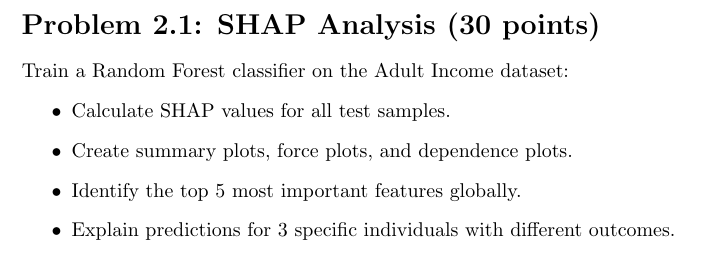

Determining the seed
Read CSV file with adult income data, feature “Income” was set as the target and values of it were converted to a binary format from [">50K", "<=50K"] to [1, 0].
For categorical features, OneHotEncoder was used.
The data was then split into training and testing sets using `train_test_split` function

In [529]:
seed = 47

df = pd.read_csv("adult.csv.zip")
y = (df["income"] == ">50K").astype(int)
X_raw = df.drop(columns=["income"])
X_encoded = pd.get_dummies(X_raw)

X_train_enc, X_test_enc, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=seed, stratify=y
)

A Random Forest Classifier is initialized with 100 decision trees and a maximum depth of 5 to prevent overfitting. The model is trained on the encoded training data to learn the patterns associated with higher income.

In [530]:
model_RF = RandomForestClassifier(n_estimators=100, 
                      max_depth=5, 
                      random_state=seed,
                      n_jobs=-1)

model_RF.fit(X_train_enc, y_train)

RandomForestClassifier(max_depth=5, n_jobs=-1, random_state=47)

We use shap.TreeExplainer to calculate SHAP values for the test set. These values quantify how much each feature contributed to the model's prediction for every individual record. Since this is a binary classification, we focus on index 1 (the probability of earning $>50K$).

In [558]:
explainer = shap.TreeExplainer(model_RF)
shap_values = explainer.shap_values(X_test_enc)
shap_vals = shap_values[:,:,1]
print(f"shape of shap values: {shap_vals.shape}")

shape of shap values: (9769, 108)


This plot provides a overview of how features influence the model.

- Feature Importance: Features are ranked by their overall impact (top being most important).

- Direction of Impact: Each dot represents an individual. Red indicates a high feature value, while blue indicates a low value.

- Interpretation: For example, being "Married-civ-spouse" (Red) pushes the SHAP value to the right (positive), meaning it significantly increases the likelihood of being predicted as high-income.

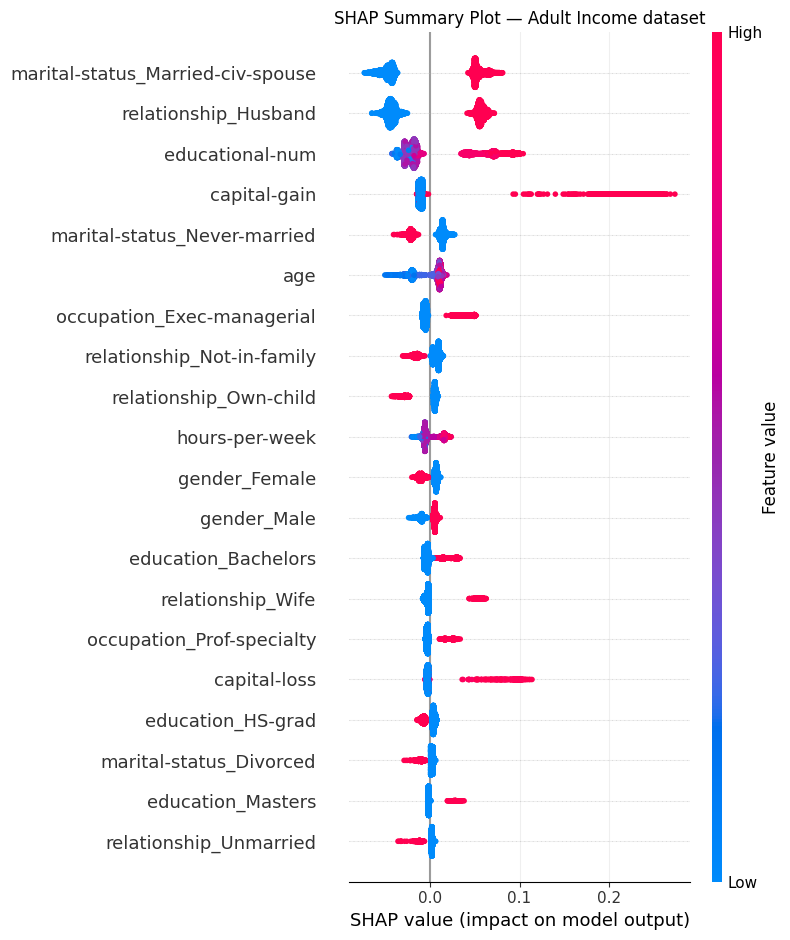

In [533]:
shap.summary_plot(shap_vals, X_test_enc, show=False)
plt.title('SHAP Summary Plot — Adult Income dataset')
plt.tight_layout()
plt.grid(alpha=0.2)
plt.show()

This is a simplified version of the summary plot. It displays the mean absolute SHAP value for each feature.

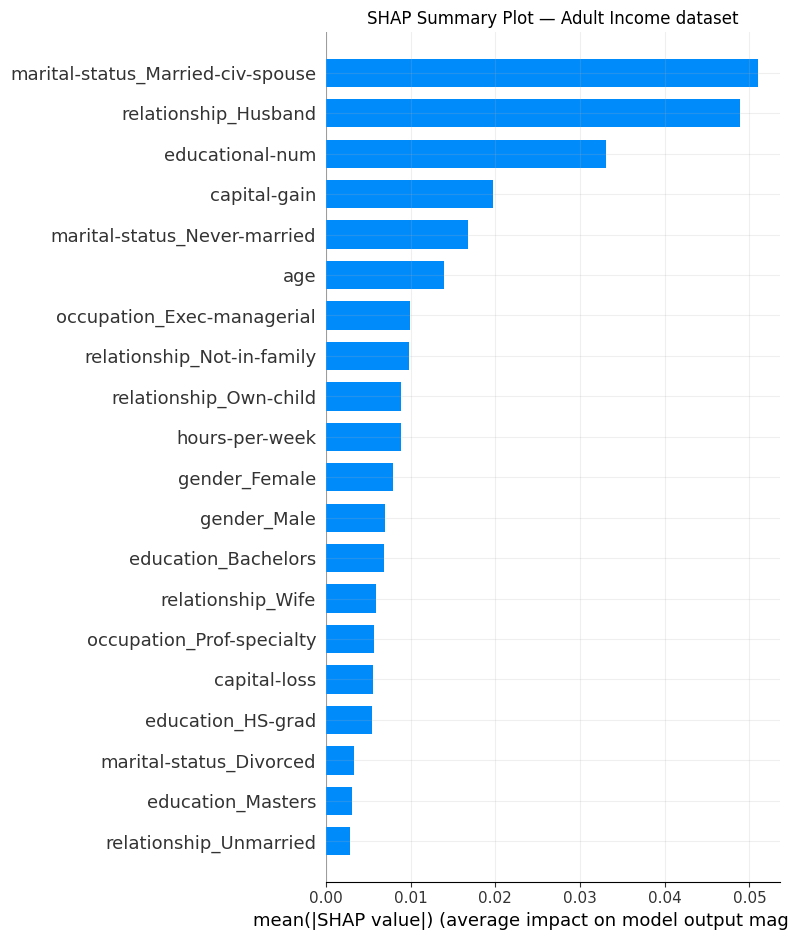

In [534]:
shap.summary_plot(shap_vals, X_test_enc, plot_type="bar",show=False)
plt.title('SHAP Summary Plot — Adult Income dataset')
plt.tight_layout()
plt.grid(alpha=0.2)
plt.show()

In [535]:
importance = np.abs(shap_vals).mean(axis=0)
feature_importance = pd.Series(importance, index=X_test_enc.columns)
feature_importance.sort_values(ascending=False).head(5)


marital-status_Married-civ-spouse    0.051062
relationship_Husband                 0.048900
educational-num                      0.033032
capital-gain                         0.019774
marital-status_Never-married         0.016825
dtype: float64

This plot shows the relationship between the number of years of education and its impact on the prediction.

Trend: There is a clear "step" around 12–13 years of education. Below 12, the impact is negative; above 13, the SHAP value jumps significantly, showing that higher education is a strong positive predictor for high income.

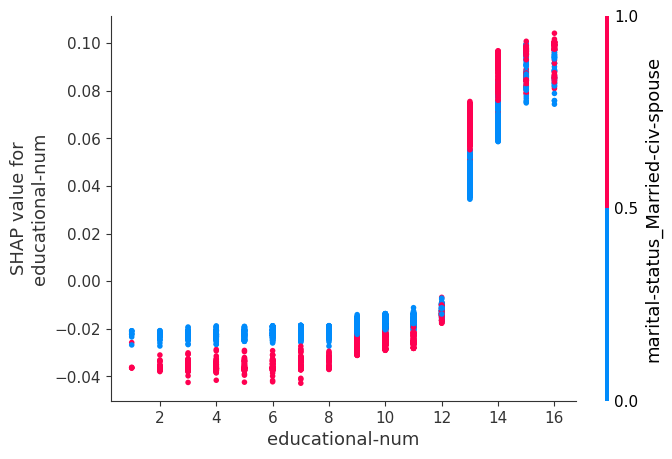

In [536]:
shap.dependence_plot("educational-num", shap_vals, X_test_enc)

The model suggests that the likelihood of earning over $\$50K$  with age, with a significant jump observed among people over the age of 30

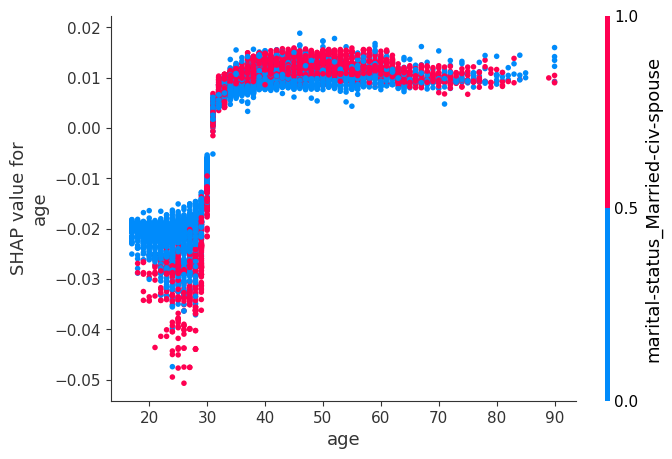

In [537]:
shap.dependence_plot("age", shap_vals, X_test_enc)

After making predictions with the Random Forest model, we compare them against the actual labels. We identify specific examples of:
- True Positive (TP),
- True Negative (TN),
- False Positive (FP).

In [539]:
y_pred = model_RF.predict(X_test_enc)

results = pd.DataFrame({
    "true": y_test,
    "pred": y_pred
})
tp = results[(results.true == 1) & (results.pred == 1)].index[0]
tn = results[(results.true == 0) & (results.pred == 0)].index[0]
fp = results[(results.true == 0) & (results.pred == 1)].index[0]

To understand an individual prediction, we use a SHAP Force Plot. This visualization shows how the model pushes the prediction from the base value to the final output value $f(x)$.

- Base Value ($0.2392$): This is the average probability of earning $>50K$ in the training set.
- Output Value ($0.55$): The model's final predicted probability for this specific person is $55\%$, which is higher than the base value.
- Red Bars (Positive Impact): These features push the prediction higher (toward $>50K$). The strongest drivers for this person:
    - Education-num = 13:,
    - Marital-status_Married-civ-spouse = 1
    - relationship_Husband = 1.
- Blue Bars (Negative Impact): These features push the prediction lower. Capital-gain = 0: The lack of capital gains is pulling the prediction down slightly, preventing it from being even higher.

Conclusion: For this individual, their high education level and marital status were enough to overcome the lack of capital gains, leading the model to correctly predict them as a high-income earner.

In [540]:
explainer = shap.TreeExplainer(model_RF)
shap_values = explainer.shap_values(X_test_enc)

pos = X_test_enc.index.get_loc(tp)

shap.plots.force(explainer.expected_value[1], shap_values[pos][:,1], X_test_enc.loc[tp,:])

In [541]:
explainer = shap.TreeExplainer(model_RF)
shap_values = explainer.shap_values(X_test_enc)

pos = X_test_enc.index.get_loc(fp)

shap.plots.force(explainer.expected_value[1], shap_values[pos][:,1], X_test_enc.loc[fp,:])

In [542]:
explainer = shap.TreeExplainer(model_RF)
shap_values = explainer.shap_values(X_test_enc)

pos = X_test_enc.index.get_loc(tn)

shap.plots.force(explainer.expected_value[1], shap_values[pos][:,1], X_test_enc.loc[tn,:])

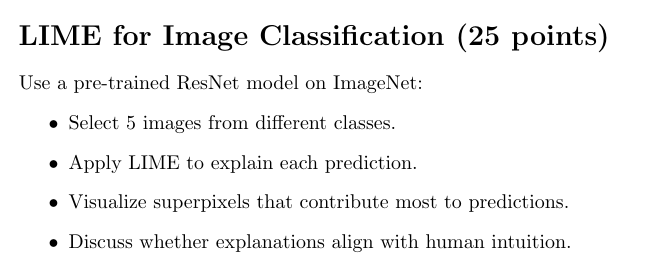

In [ ]:
cool_number = 17

#1. load the pre-trained ResNet model (ResNet18)
weights = models.ResNet18_Weights.DEFAULT #you can also try ResNet50: larger but slower
model = models.resnet18(weights=weights)
model.eval()
categories = weights.meta["categories"]

# 2 load 5 pictures
image_dir = '/Users/marysia/Desktop/applied/ml/applied/images'
img_files = sorted([str(Path(image_dir) / f) for f in os.listdir(image_dir)
                    if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

selected_paths = img_files[:5]  # select first 5 (ensure they are from different classes if possible)

explainer = lime_image.LimeImageExplainer(random_state=cool_number)

def predict_fn(images):
    # images: list/array of HxWx3 uint8
    batch = torch.stack([preprocess(Image.fromarray(im.astype(np.uint8))) for im in images]).to('cpu')
    with torch.no_grad():
        out = model(batch)
        probs = F.softmax(out, dim=1).cpu().numpy()
    return probs

def visualize_explanation(explanation, img_array, top_class, categories, top_k=3, num_features=10):
    # show original and LIME mask (positive contributions) and overlay top_k superpixels
    plt.figure(figsize=(12,5))

    plt.subplot(1,3,1)
    plt.imshow(img_array)
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1,3,2)
    explained_img_pos, mask_pos = explanation.get_image_and_mask(
        top_class, positive_only=False, num_features=num_features, hide_rest=False
    )
    plt.imshow(mark_boundaries(explained_img_pos/255.0, mask_pos))
    plt.title("LIME")
    plt.axis('off')

    # build overlay of top_k contributing superpixels by weight
    segs = explanation.segments
    exp_map = dict(explanation.local_exp[top_class])  # list of (superpixel_id, weight)
    # select top_k positive superpixels
    pos_feats = sorted([ (fid, w) for fid,w in exp_map.items() if w>0 ],
                       key=lambda x: -x[1])[:top_k]
    mask = np.zeros(segs.shape, dtype=bool)
    for fid, w in pos_feats:
        mask[segs == fid] = True

    overlay = img_array.copy().astype(float) / 255.0
    # dim non-selected regions
    overlay[~mask] *= 0.25

    plt.subplot(1,3,3)
    plt.imshow(mark_boundaries(overlay, mask))
    plt.title(f"Top {top_k} contributing superpixels")
    plt.axis('off')

    plt.suptitle(f"Predicted: {categories[top_class]}")
    plt.show()

    #green = supports prediction, red = contradicts

def superpixel_importance(explanation, top_class):
    exp_map = dict(explanation.local_exp[top_class])  # list of (superpixel_id, weight)
    print("Feature ID | Importance Weight")
    print("----------------------------")
    for feature_id, weight in sorted(exp_map.items(), key=lambda x: -abs(x[1]))[:10]: #top 10 most important superpixels
        print(f"{feature_id:^10} | {weight:.4f}")

# loop through 5 images

def main(p):
    #3. preprocess the image
    img = Image.open(p).convert('RGB')
    img_array = np.array(img.resize((224,224)))
    #4. make a prediction
    preds = predict_fn([img_array])[0]
    top5_idx = preds.argsort()[-5:][::-1]
    print("\nImage:", p)
    for i, idx in enumerate(top5_idx, 1):
        print(f"{i:>2}. {categories[idx]:<30} {preds[idx]*100:6.2f}%")

    #5. get lime explanations
    explanation = explainer.explain_instance(
        img_array,
        predict_fn,
        top_labels=5,
        num_samples=1000,
        random_seed=cool_number
    )
    top_class = explanation.top_labels[0]
    #6. visualize the explanation
    visualize_explanation(explanation, img_array, top_class, categories, top_k=3, num_features=10)

    #7. map of all superpixels
    segments = explanation.segments
    plt.figure(figsize=(5, 5))
    plt.imshow(segments, cmap='nipy_spectral')
    plt.colorbar(label="Superpixel ID")
    plt.title("Map of all Superpixel IDs")

    for label in np.unique(segments):
        y, x = np.where(segments == label)
        plt.text(x.mean(), y.mean(), str(label),
                color='white', weight='bold', ha='center', va='center')

    plt.axis('off')
    plt.show()
    #8. importance weights for all superpixels
    superpixel_importance(explanation, top_class)


Image: /Users/marysia/Desktop/applied/ml/applied/images/093.jpg
 1. barbell                         92.50%
 2. plunger                          3.00%
 3. dumbbell                         2.23%
 4. spindle                          1.91%
 5. screwdriver                      0.26%


100%|██████████| 1000/1000 [00:21<00:00, 46.52it/s]


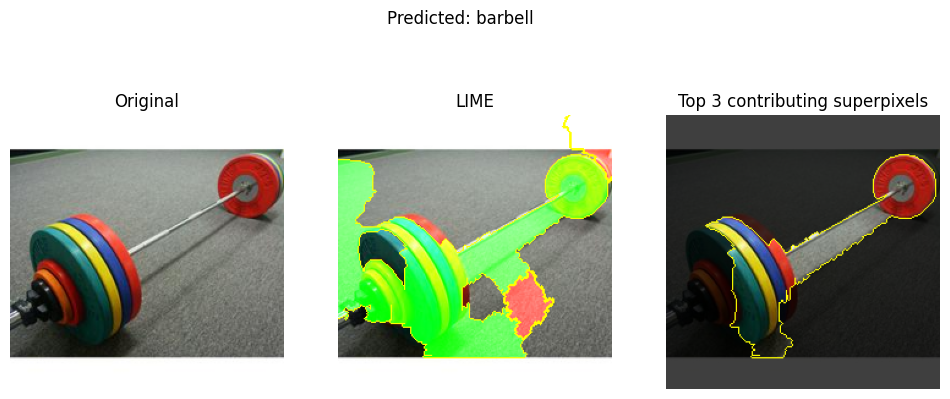

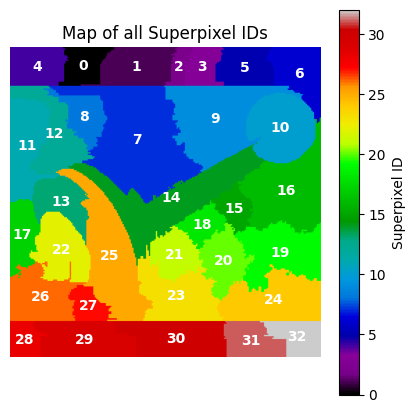

Feature ID | Importance Weight
----------------------------
    10     | 0.2855
    25     | 0.2172
    14     | 0.1966
    22     | 0.1581
    17     | 0.1420
    23     | 0.0790
    6      | -0.0615
    18     | 0.0453
    11     | 0.0419
    20     | -0.0314


In [ ]:
main(selected_paths[0])

* Prediction: correct
* Explanation: reasonable, plates give away what the object is (random fragment 'contradicing' that prediction a bit absurd tho)
* Verdict: LIME aligns with human intuition


Image: /Users/marysia/Desktop/applied/ml/applied/images/104.jpg
 1. Arctic fox                      99.79%
 2. white wolf                       0.10%
 3. kit fox                          0.06%
 4. Samoyed                          0.04%
 5. grey fox                         0.01%


100%|██████████| 1000/1000 [00:20<00:00, 48.56it/s]


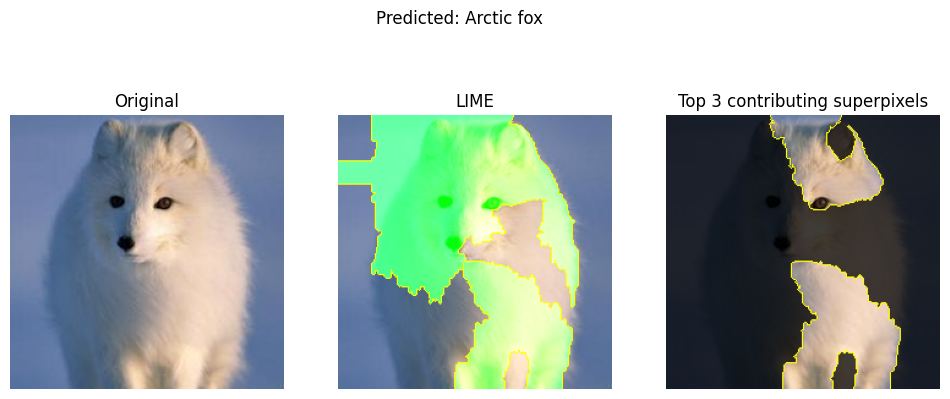

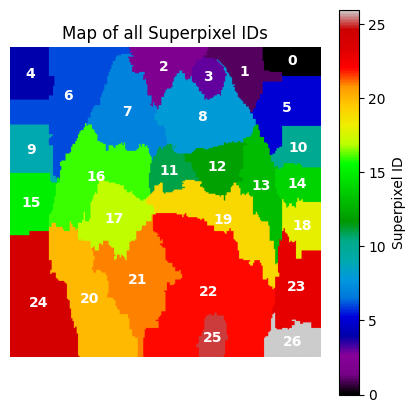

Feature ID | Importance Weight
----------------------------
    8      | 0.5419
    2      | 0.2109
    22     | 0.1738
    7      | 0.1302
    16     | 0.1113
    11     | 0.1065
    3      | 0.1025
    6      | 0.0697
    17     | 0.0569
    13     | 0.0494


In [ ]:
main(selected_paths[1])

* Prediction: correct
* Explanation: fur and ears are important, which makes sense, but the nose and whole face would be more intuitive for a human
* Verdict: LIME somehow aligns with human intuition


Image: /Users/marysia/Desktop/applied/ml/applied/images/261.jpg
 1. bow tie                         99.88%
 2. muzzle                           0.05%
 3. Windsor tie                      0.02%
 4. brassiere                        0.02%
 5. hair slide                       0.01%


100%|██████████| 1000/1000 [00:20<00:00, 48.04it/s]


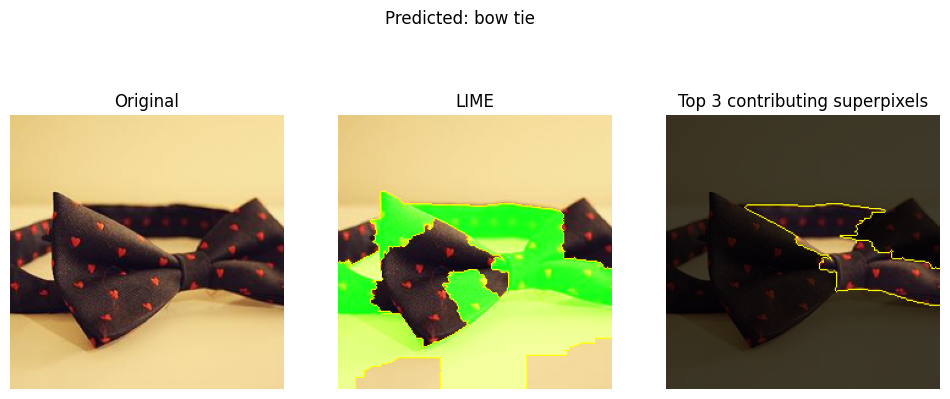

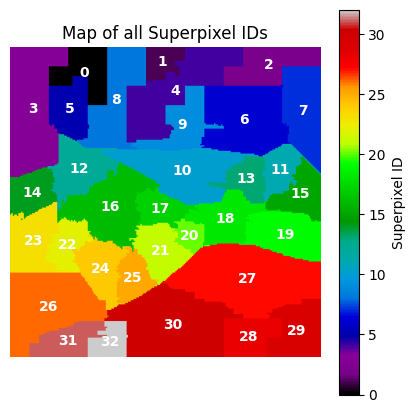

Feature ID | Importance Weight
----------------------------
    10     | 0.2484
    19     | 0.2111
    18     | 0.1949
    21     | 0.1752
    27     | 0.1579
    30     | 0.1386
    13     | 0.1231
    12     | 0.1084
    23     | 0.1065
    26     | 0.0952


In [ ]:
main(selected_paths[2])

* Prediction: correct
* Explanation: doesn't make much sense for a human, the shape of the main part would give it away way faster then the pixels chosen by the model
* Verdict: LIME doesn't align with human intuition


Image: /Users/marysia/Desktop/applied/ml/applied/images/522.jpg
 1. abacus                          99.99%
 2. croquet ball                     0.01%
 3. maraca                           0.00%
 4. dumbbell                         0.00%
 5. confectionery                    0.00%


100%|██████████| 1000/1000 [00:19<00:00, 50.00it/s]


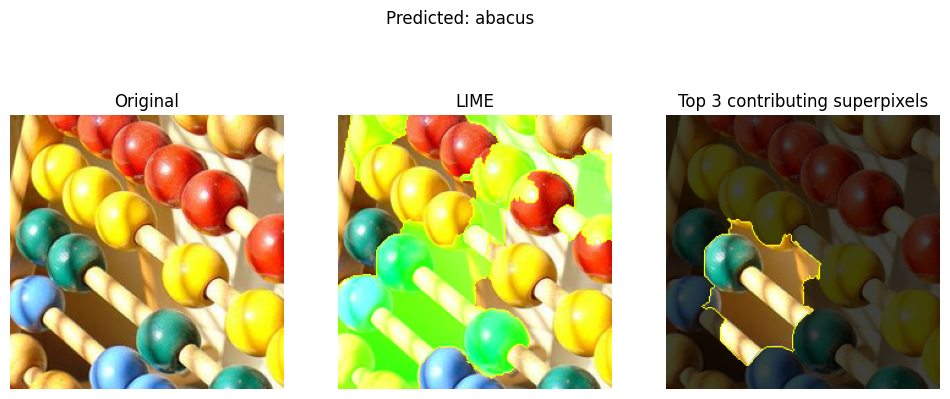

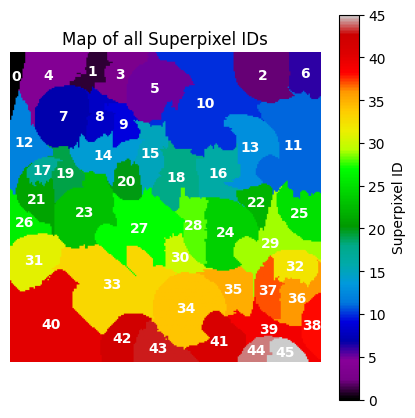

Feature ID | Importance Weight
----------------------------
    33     | 0.3182
    27     | 0.2688
    23     | 0.2241
    34     | 0.1665
    40     | 0.1658
    10     | 0.1339
    31     | 0.1009
    18     | 0.0914
    4      | 0.0848
    11     | 0.0723


In [ ]:
main(selected_paths[3])

* Prediction: correct
* Explanation: reasonable
* Verdict: LIME aligns with human intuition


Image: /Users/marysia/Desktop/applied/ml/applied/images/607.jpg
 1. birdhouse                       98.10%
 2. chime                            1.59%
 3. bell cote                        0.16%
 4. church                           0.05%
 5. ocarina                          0.02%


100%|██████████| 1000/1000 [00:19<00:00, 50.88it/s]


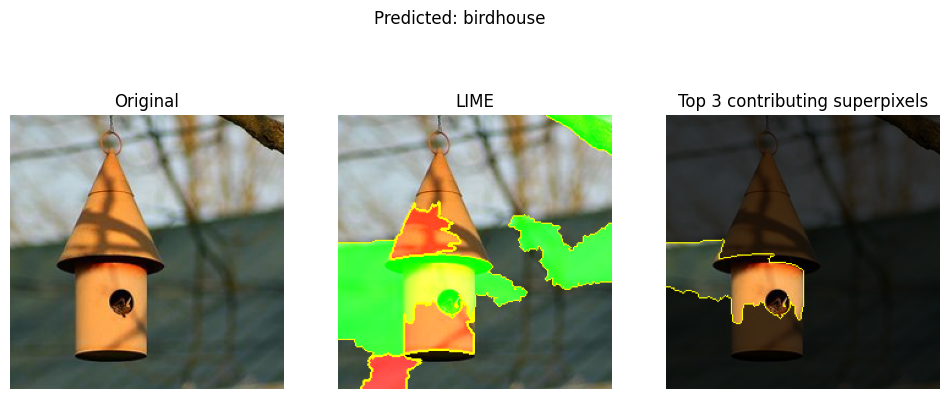

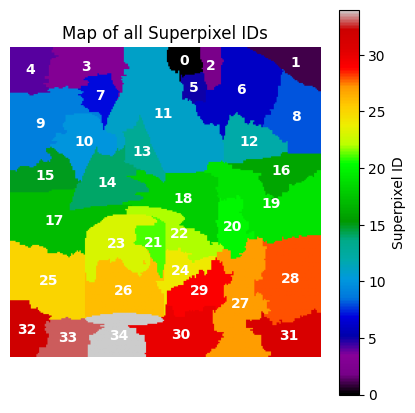

Feature ID | Importance Weight
----------------------------
    23     | 0.3690
    17     | 0.0828
    21     | 0.0811
    22     | 0.0693
    1      | 0.0546
    26     | -0.0507
    14     | -0.0478
    19     | 0.0459
    33     | -0.0434
    25     | 0.0390


In [ ]:
main(selected_paths[4])

* Prediction: correct
* Explanation: reasonable (the hole, the background makes sense, although the 'contradicting' superpixels a bit random)
* Verdict: LIME somehow aligns with human intuition

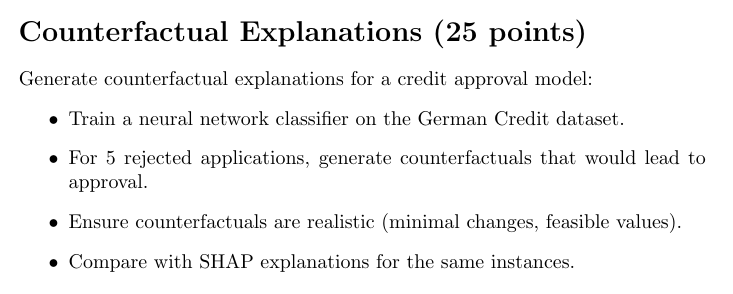

Read CSV file with German Credit data, feature “credit_risk” was set as the target.
The data was then split into training and testing sets using `train_test_split` function

In [583]:
df = pd.read_csv("German_Credit_data.csv", dtype=int)
y = df["credit_risk"]
X = df.drop(columns=["credit_risk"])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=seed)



Preprocessing: We use a ColumnTransformer to handle two types of data:

- Numerical: Scaled using StandardScaler so the neural network treats them equally.

- Categorical: Transformed using OneHotEncoder to create binary features.

In [584]:
# num_cols = X_train.select_dtypes(include=['number']).columns.tolist()
# cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = [
    "duration",
    "amount",
    "age"
]
cat_cols = [
    "status",
    "credit_history",
    "purpose",
    "savings",
    "employment_duration",
    "installment_rate",
    "personal_status_sex",
    "other_debtors",
    "present_residence",
    "property",
    "other_installment_plans",
    "housing",
    "number_credits",
    "job",
    "people_liable",
    "telephone",
    "foreign_worker"
]
target = "credit_risk"


In [ ]:
preprocessor = ColumnTransformer(transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

Model: We use a Multi-Layer Perceptron (MLP), a type of neural network. The architecture has two hidden layers ($32$ and $16$ neurons), allowing it to capture complex, non-linear relationships in the credit data.

In [586]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=500, random_state=seed))
])
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['duration', 'amount',
                                                   'age']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['status', 'credit_history',
                                                   'purpose', 'savings',
                                                   'employment_duration',
                                                   'installment_rate',
                                                   'personal_status_sex',
                                                   'other_debtors',
                                                   'present_residence',
                                                   'property',
                                                   'other_installment_plans',
                                                   'housing', 'number_credits',
                                                   'job', 'people_liable',
                                                   'telephone',
                                                   'foreign_worker'])])),
                ('classifier',
                 MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=500,
                               random_state=47))])

- Accuracy (70%): The model correctly identifies the risk in $70\%$ of cases.
- ROC-AUC (0.713): An AUC of $0.71$ indicates the model has a "fair" ability to distinguish between high-risk and low-risk applicants. It is significantly better than random guessing ($0.5$), but suggests some room for improvement.
- Class Imbalance: Notice that class 1 (Good Risk) has much higher recall ($0.78$) than class 0 (Bad Risk). The model is better at spotting safe bets than dangerous ones.

In [587]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.51      0.53      0.52        60
           1       0.80      0.78      0.79       140

    accuracy                           0.70       200
   macro avg       0.65      0.66      0.65       200
weighted avg       0.71      0.70      0.71       200

ROC-AUC: 0.7130952380952381


This part of the code answers the question: "If my loan was rejected, what is the smallest change I can make to be accepted?"

In [588]:
rejected_idx = np.where(y_pred == 0)[0]
X_rejected = X_test.iloc[rejected_idx]

DiCE (Diverse Counterfactual Explanations): We initialize a "genetic" search to find the closest points in the feature space that result in an "Accepted" status.

In [589]:
train_df = X_train.copy()
train_df["credit_risk"] = y_train

d = dice_ml.Data(
    dataframe=train_df,
    continuous_features=num_cols,
    outcome_name="credit_risk"
)

m = dice_ml.Model(model=model, backend="sklearn")

exp = dice_ml.Dice(d, m, method="genetic")

Constraints: We limit the changes to actionable features like amount, duration, and savings... . We wouldn't want to suggest someone change their "age" to get a loan!

In [595]:
features_to_vary = [
    "amount",
    "duration",
    "savings",
    "employment_duration",
    "installment_rate",
    "job"
]

permitted_range = {
    "amount": [500, 20000],
    "duration": [6, 72],
    "savings":['1', '2', '3', '4', '5'],
    "employment_duration":['1', '2', '3', '4', '5'],
    "installment_rate":['1', '2', '3', '4'],
    "job":['1', '2', '3', '4']
}

In [596]:
cf_examples = []

for i in range(len(X_rejected)):
    cf = exp.generate_counterfactuals(
        X_rejected.iloc[i:i+1],
        total_CFs=3,
        desired_class="opposite",
        features_to_vary=features_to_vary,
        permitted_range=permitted_range
    )
    cf_examples.append(cf)

100%|██████████| 1/1 [00:00<00:00,  1.82it/s]


The output table shows the original rejected case (top) and 3 counterfactuals (bottom).

In [ ]:
cf.visualize_as_dataframe(show_only_changes=True)

Query instance (original outcome : 0)


,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,4,42,2,3,7166,5,4,2,4,1,...,2,29,3,1,1,3,2,2,2,0



Diverse Counterfactual set (new outcome: 1)


,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,-,30,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,1
0,-,30,-,-,-,1,-,-,-,-,...,-,-,-,-,-,-,-,-,-,1
0,-,30,-,-,-,1,1,-,-,-,...,-,-,-,-,-,-,-,-,-,1


In [ ]:
explainer = shap.Explainer(model.predict, X_train)
shap_values = explainer(X_test.iloc[rejected_idx])

PermutationExplainer explainer: 64it [00:10,  3.46s/it]                        


Since SHAP values for neural networks are computationally expensive, we use shap.Explainer on the model's prediction function. The Waterfall Plot shows the journey from the average prediction to this specific person's score.

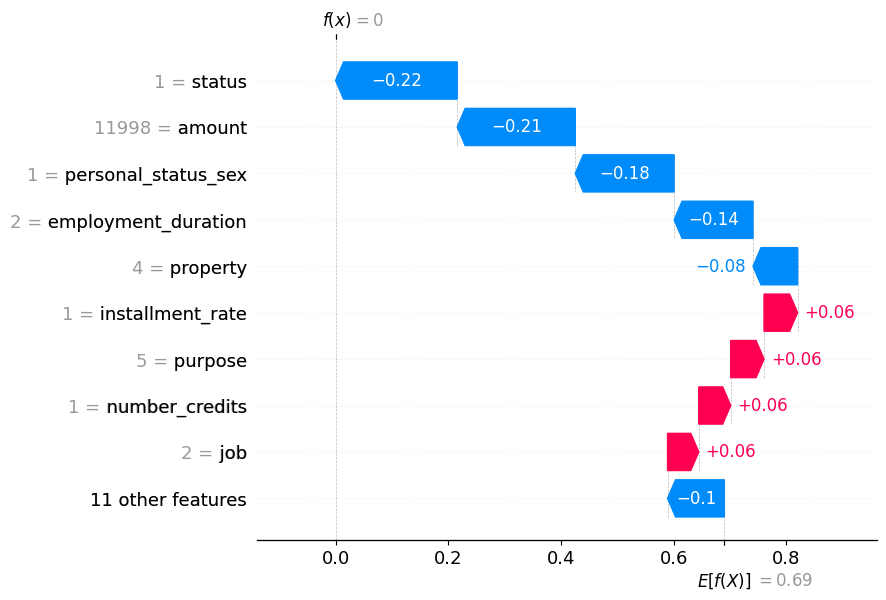

In [ ]:
shap.plots.waterfall(shap_values[10])

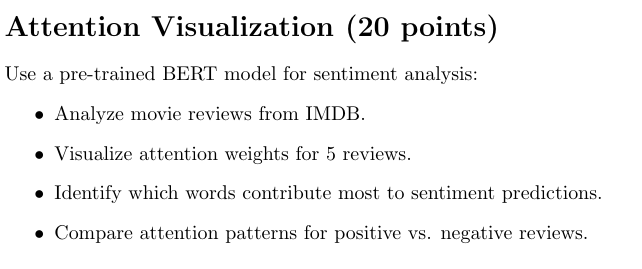

In [ ]:
with open("token.txt", "r", encoding="utf-8") as f:
    token = f.read().strip()
login(token)

In [ ]:
del model
import gc
gc.collect()

45

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

...

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]


--- Analyzing Review ---
Original Review: I love sci-fi and am willing to put up with a lot. Sci-fi movies/TV are usually underfunded, under-appreciated and misunderstood. I tried to like this...
Cleaned review: love scifi willing put lot Scifi moviesTV usually underfunded underappreciated misunderstood tried like really good TV scifi Babylon 5 Star Trek origi...
True Sentiment: NEGATIVE
Predicted Sentiment: NEGATIVE
Confidence: 99.79%


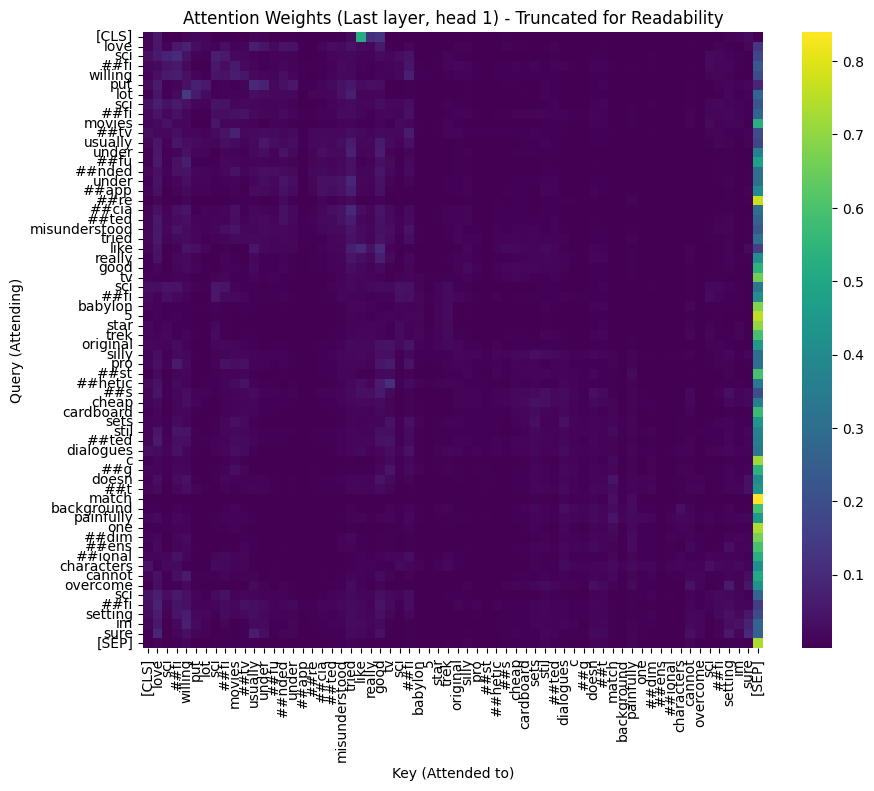

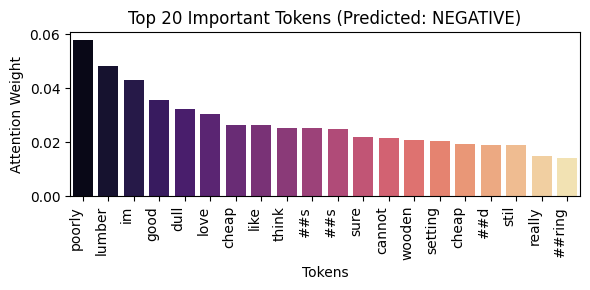


--- Analyzing Review ---
Original Review: Worth the entertainment value of a rental, especially if you like action movies. This one features the usual car chases, fights with the great Van Dam...
Cleaned review: Worth entertainment value rental especially like action movies one features usual car chases fights great Van Damme kick style shooting battles 40 she...
True Sentiment: NEGATIVE
Predicted Sentiment: POSITIVE
Confidence: 92.91%


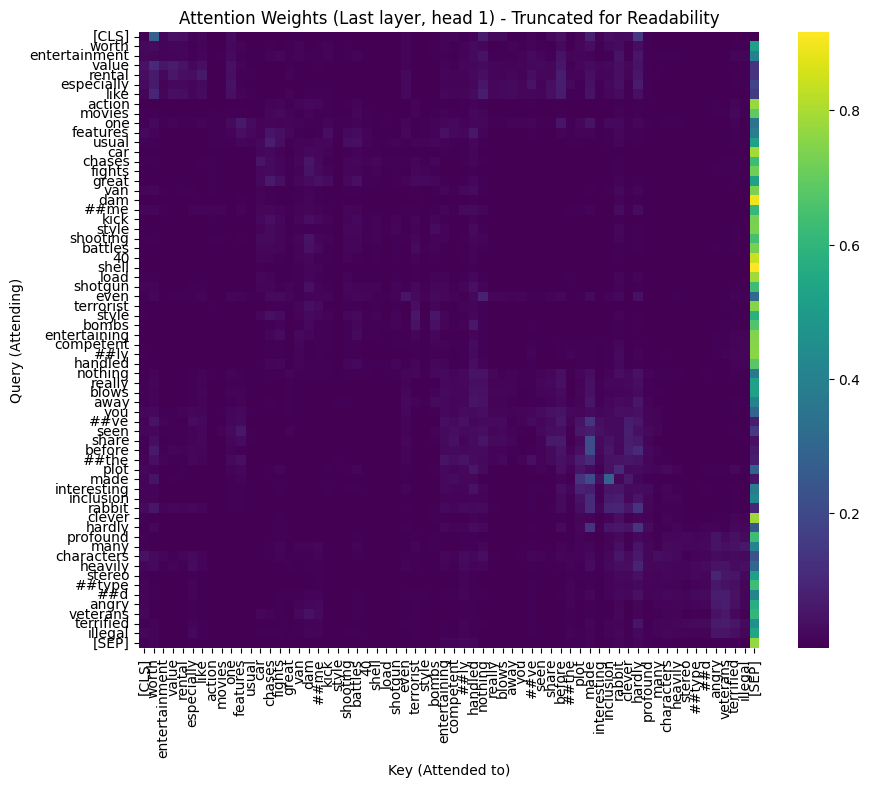

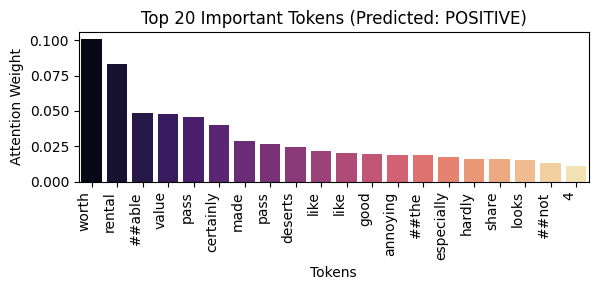


--- Analyzing Review ---
Original Review: Previous reviewer Claudio Carvalho gave a much better recap of the film's plot details than I could. What I recall mostly is that it was just so beaut...
Cleaned review: Previous reviewer Claudio Carvalho gave much better recap films plot details could recall mostly beautiful every sense emotionally visually editoriall...
True Sentiment: POSITIVE
Predicted Sentiment: POSITIVE
Confidence: 99.91%


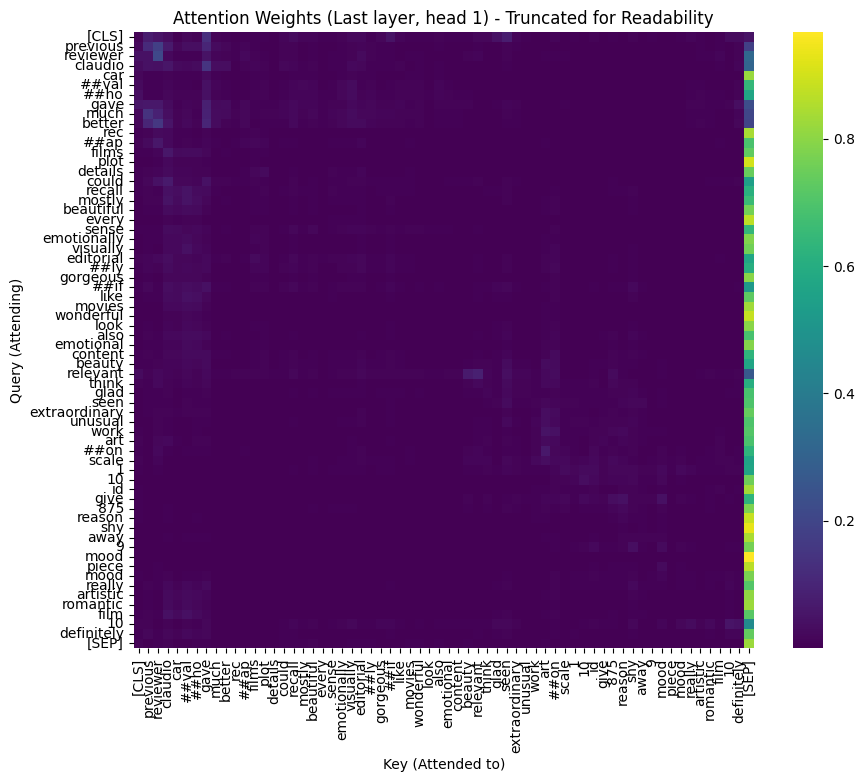

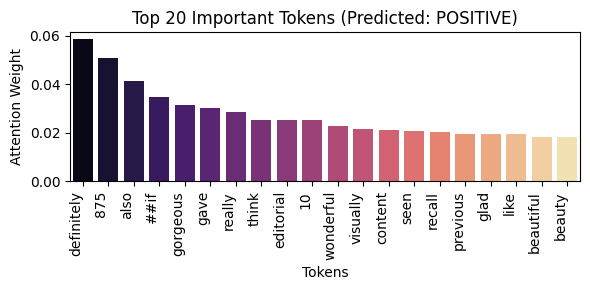


--- Analyzing Review ---
Original Review: CONTAINS "SPOILER" INFORMATION. Watch this director's other film, "Earth", at some point. It's a better film, but this one isn't bad just different.<b...
Cleaned review: CONTAINS SPOILER INFORMATION Watch directors film Earth point better film one isnt bad differentA rare feminist point view Indian filmmaker Tradition ...
True Sentiment: POSITIVE
Predicted Sentiment: POSITIVE
Confidence: 94.06%


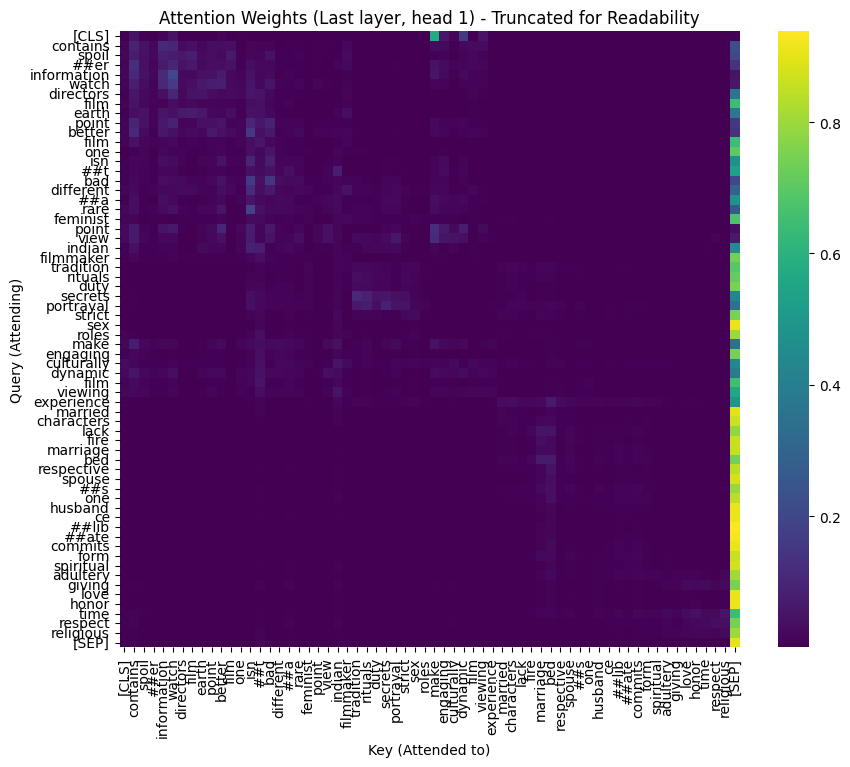

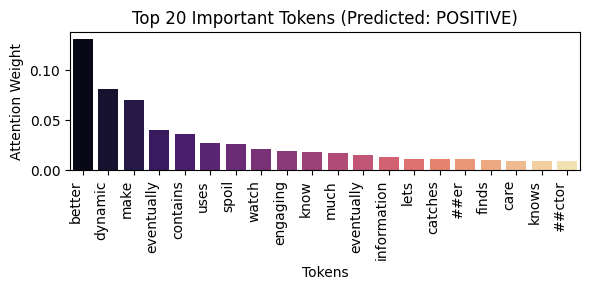


--- Analyzing Review ---
Original Review: This is my first Deepa Mehta film. I saw the film on TV in its Hindi version with its "Sita" character presented as Nita. I also note that it is Radha...
Cleaned review: first Deepa Mehta film saw film TV Hindi version Sita character presented Nita also note Radha underwent allegorical trial fire film NitaSita Yet love...
True Sentiment: POSITIVE
Predicted Sentiment: NEGATIVE
Confidence: 63.12%


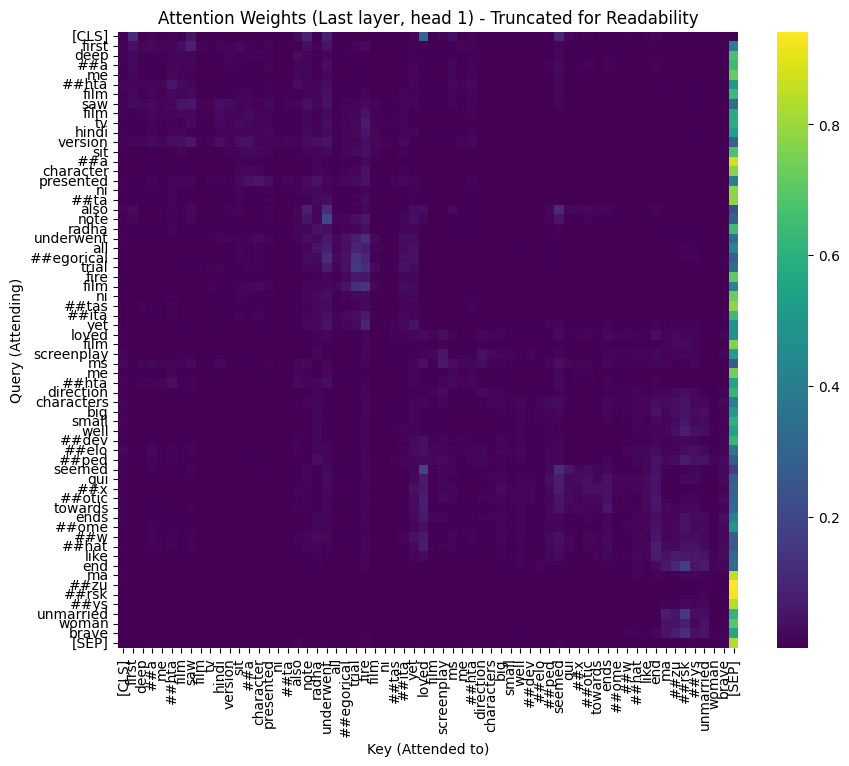

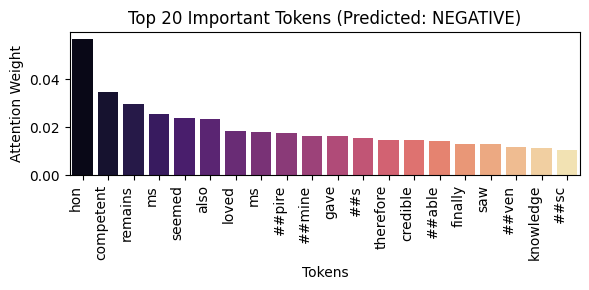

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns, string
import re # Import the regular expression module

#1. Load the BERT model (pre-trained for sentiment analysis) with its tokenizer
model_name = "distilbert-base-uncased-finetuned-sst-2-english"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, output_attentions=True)
model.eval()

imdb_test = load_dataset("imdb", split="test")

# Helper function to analyze and visualize attention for a single review
def analyze_review(review_text, review_label, top_k_tokens_for_plot=20):
    print(f"\n--- Analyzing Review ---")

    # Remove HTML tags and '###' signs, then normalize whitespace
    clean_review_text = re.sub(r'<.*?>|#+', '', review_text) # Remove HTML tags and '#'
    clean_review_text = re.sub('\n', '', clean_review_text)
    clean_review_text = re.sub(r'\s+', ' ', clean_review_text).strip() # Normalize whitespace

    # Remove punctuation and hyphens
    clean_review_text = clean_review_text.translate(str.maketrans('', '', string.punctuation.replace('-', '')))
    clean_review_text = clean_review_text.replace('-', '')

    # Filter out stop words
    words = clean_review_text.split()
    filtered_words = [word for word in words if word.lower() not in stop_words]
    clean_review_text = " ".join(filtered_words)

    print(f"Original Review: {review_text[:150]}...")
    print(f"Cleaned review: {clean_review_text[:150]}...")
    sentiment_label = "POSITIVE" if review_label == 1 else "NEGATIVE"
    print(f"True Sentiment: {sentiment_label}")
    #2. Prepare the input - use max_length=512 for full analysis, but still truncate if review is longer
    inputs = tokenizer(clean_review_text, return_tensors="pt", truncation=True, max_length=512)
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

    #3. Forward pass
    with torch.no_grad():
        outputs = model(**inputs)
        attentions = outputs.attentions

    #4. Get the sentiment prediction
    logits = outputs.logits
    probs = F.softmax(logits, dim=-1)
    prediction_idx = torch.argmax(probs).item()
    predicted_label = model.config.id2label[prediction_idx]
    confidence = probs[0][prediction_idx].item()

    print(f"Predicted Sentiment: {predicted_label}")
    print(f"Confidence: {confidence:.2%}")

    # 5. Visualize attention for [CLS] token (heatmap for raw attention matrix - optional and potentially large)
    # If the sequence length is too long, this plot becomes unreadable. We will keep max_length at 64 for this specific plot.
    # For the heatmap, we will use a truncated version to keep it readable, as discussed earlier.
    heatmap_inputs = tokenizer(clean_review_text, return_tensors="pt", truncation=True, max_length=64)
    heatmap_tokens = tokenizer.convert_ids_to_tokens(heatmap_inputs["input_ids"][0])

    # Rerun model with truncated input for heatmap visualization only
    with torch.no_grad():
        heatmap_outputs = model(**heatmap_inputs)
        heatmap_attentions = heatmap_outputs.attentions

    head = 0 #0,...,11
    attention_matrix = heatmap_attentions[-1][0, head].detach().numpy() #-1 denotes the last layer (distilbert has 6 layers, 12 heads)

    plt.figure(figsize=(10, 8))
    sns.heatmap(attention_matrix, xticklabels=heatmap_tokens, yticklabels=heatmap_tokens,
                annot=False, cmap="viridis")
    plt.title(f"Attention Weights (Last layer, head {head+1}) - Truncated for Readability")
    plt.xlabel("Key (Attended to)")
    plt.ylabel("Query (Attending)")
    plt.show()

    #6. Calculate average attention for [CLS] token and all heads using the full input
    last_layer = attentions[-1][0] # attentions is a tuple of (layer, batch, head, seq_len, seq_len)
    avg_attn = last_layer.mean(dim=0)
    cls_attention = avg_attn[0].detach().numpy() # [CLS] token is at index 0

    # Filter out special tokens and stop words for visualization
    processed_tokens = []
    processed_cls_attention = []
    for i, token in enumerate(tokens):
        # NLTK stop words are lowercase, so convert token to lowercase for comparison
        if token not in ['[CLS]', '[SEP]'] and token.lower() not in stop_words:
            processed_tokens.append(token)
            processed_cls_attention.append(cls_attention[i])

    # Sort by attention weight and select top_k_tokens_for_plot
    sorted_indices = np.argsort(processed_cls_attention)[::-1] # Sort in descending order
    top_k_tokens = [processed_tokens[i] for i in sorted_indices[:top_k_tokens_for_plot]]
    top_k_cls_attention = [processed_cls_attention[i] for i in sorted_indices[:top_k_tokens_for_plot]]

    plt.figure(figsize=(6, 3))
    x_pos = range(len(top_k_tokens))
    sns.barplot(x=x_pos, y=top_k_cls_attention, palette="magma")
    plt.title(f"Top {top_k_tokens_for_plot} Important Tokens (Predicted: {predicted_label})")
    plt.xticks(x_pos, top_k_tokens, rotation=90, ha="right")
    plt.ylabel("Attention Weight")
    plt.xlabel("Tokens")
    plt.tight_layout()
    plt.show()

# Select 5 reviews
selected_reviews = [
    imdb_test[0], # Negative
    imdb_test[1], # Negative
    imdb_test[12500], # Positive
    imdb_test[12501], # Positive
    imdb_test[12502]  # Positive
]

# Analyze each selected review
for review in selected_reviews:
    analyze_review(review['text'], review['label'])

**Comparison:**
- predicted as negative: <ul>
    - good - that one is surprising
    - poorly
    - lumber / wooden
    - tiring
    - dull
    - cheap
    - value
    - worth - note that this can be both in posotive and negative reviews
    - rental - 
    - annoying
    </ul>
- positive reviews: <ul>
    - gorgeus
    - better
    - beautiful
    - dynamic
    - engaging
    - catches
    - surprises
    </ul>
Algorithm wrongly predicted positive when the review was negative and the other way.

1st (negative - negative)

I love sci-fi and am willing to put up with a lot. Sci-fi movies/TV are usually underfunded, under-appreciated and misunderstood. I tried to like this, I really did, but it is to good TV sci-fi as Babylon 5 is to Star Trek (the original). Silly prosthetics, cheap cardboard sets, stilted dialogues, CG that doesn't match the background, and painfully one-dimensional characters cannot be overcome with a 'sci-fi' setting. (I'm sure there are those of you out there who think Babylon 5 is good sci-fi TV. It's not. It's clichéd and uninspiring.) While US viewers might like emotion and character development, sci-fi is a genre that does not take itself seriously (cf. Star Trek). It may treat important issues, yet not as a serious philosophy. It's really difficult to care about the characters here as they are not simply foolish, just missing a spark of life. Their actions and reactions are wooden and predictable, often painful to watch. The makers of Earth KNOW it's rubbish as they have to always say "Gene Roddenberry's Earth..." otherwise people would not continue watching. Roddenberry's ashes must be turning in their orbit as this dull, cheap, poorly edited (watching it without advert breaks really brings this home) trudging Trabant of a show lumbers into space. Spoiler. So, kill off a main character. And then bring him back as another actor. Jeeez! Dallas all over again. 

2nd (negative, predicted as positive)

Worth the entertainment value of a rental, especially if you like action movies. This one features the usual car chases, fights with the great Van Damme kick style, shooting battles with the 40 shell load shotgun, and even terrorist style bombs. All of this is entertaining and competently handled but there is nothing that really blows you away if you've seen your share before.<br /><br />The plot is made interesting by the inclusion of a rabbit, which is clever but hardly profound. Many of the characters are heavily stereotyped -- the angry veterans, the terrified illegal aliens, the crooked cops, the indifferent feds, the bitchy tough lady station head, the crooked politician, the fat federale who looks like he was typecast as the Mexican in a Hollywood movie from the 1940s. All passably acted but again nothing special.<br /><br />I thought the main villains were pretty well done and fairly well acted. By the end of the movie you certainly knew who the good guys were and weren't. There was an emotional lift as the really bad ones got their just deserts. Very simplistic, but then you weren't expecting Hamlet, right? The only thing I found really annoying was the constant cuts to VDs daughter during the last fight scene.<br /><br />Not bad. Not good. Passable 4. 

3rd (positive - positivee)

Previous reviewer Claudio Carvalho gave a much better recap of the film's plot details than I could. What I recall mostly is that it was just so beautiful, in every sense - emotionally, visually, editorially - just gorgeous.<br /><br />If you like movies that are wonderful to look at, and also have emotional content to which that beauty is relevant, I think you will be glad to have seen this extraordinary and unusual work of art.<br /><br />On a scale of 1 to 10, I'd give it about an 8.75. The only reason I shy away from 9 is that it is a mood piece. If you are in the mood for a really artistic, very romantic film, then it's a 10. I definitely think it's a must-see, but none of us can be in that mood all the time, so, overall, 8.75. 

4th (positive - positive)

CONTAINS "SPOILER" INFORMATION. Watch this director's other film, "Earth", at some point. It's a better film, but this one isn't bad just different.<br /><br />A rare feminist point of view from an Indian filmmaker. Tradition, rituals, duty, secrets, and the portrayal of strict sex roles make this an engaging and culturally dynamic film viewing experience. All of the married characters lack the "fire" of the marriage bed with their respective spouses. One husband is celibate and commits a form of spiritual "adultery" by giving all of his love, honor, time and respect to his religious swami (guru). His wife is lonely and yearns for intimacy and tenderness which she eventually finds with her closeted lesbian sister-in-law who comes to live in their house with her unfaithful husband. This unfaithful husband is openly in love with his Chinese mistress but was forced into marriage with a (unbeknownest to him) lesbian. They only have sex once when his closet lesbian wife loses her virginity.<br /><br />A servant lives in the house and he eventually reveals the secret that the two women are lovers. Another significant character is the elderly matriarch who is unable to speak or care for herself due to a stroke. However, she uses a ringing bell to communicate her needs as well as her displeasure with the family members. She lets them know through her bell or by pounding her fist that she knows exacly what's going on in the house and how much she disapproves.<br /><br />In the end, the truth about everybody comes out and the two female lovers end up running away together. But, not before there is an emotional scene between the swami-addicted husband and his formerly straight wife. Her sari catches on fire and at first we think she is going to die. However, we see the two women united in the very last scene of the movie.<br /><br />The writer/director of this film challenges her culture's traditions, but she shows us individual human beings who are trapped by their culture and gender. We come to really care about the characters and we don't see them as stereotypes. Each on surprises us with their humanity, vulgarity, tenderness, anger, and spirit. 

5th (positive, predicted as positive)

This is my first Deepa Mehta film. I saw the film on TV in its Hindi version with its "Sita" character presented as Nita. I also note that it is Radha who underwent the allegorical trial by fire in the film and not Nita/Sita. Yet what I loved about the film was its screenplay by Ms Mehta, not her direction. The characters, big and small, were well-developed and seemed quixotic towards the end--somewhat like the end of Mazursky's "An Unmarried Woman." They are brave women surrounded by cardboard men. And one cardboard man (Ashok) seems to come alive in the last shot we see of him---carrying his invalid mother Biji. He seems to finally take on a future responsibility beyond celibacy and adherance to religion. <br /><br />Ms Mehta seems to fumble as a director (however, compared to most Indian mainstream cinema she would seem to be brilliant) as she cannot use her script to go beyond the microscopic joint family she is presenting except presenting a glimpse of the Chinese micro-minority in the social milieu of India. She even dedicates the film to her mother and daughter (not her father!) Yet her Radha reminesces of halcyon days with both her parents in a mustard field. Compare her to Mrinal Sen, Adoor Gopalakrishnan, Muzaffar Ali and she is dwarfed by these giants--given her competent Canadian production team and financial resources! Mehta's film of two bisexual ladies in an Indian middle-class household may be sacrilege to some, but merely captures the atrophy of middle-class homes that does not seem to aspire for something better than its immediate survival in a limited social space. Kannada, Malayalam, and Bengali films have touched parallel themes in India but did not have the publicity that surrounded this film and therefore have not been seen by a wide segment of knowledgeable cinemagoers.<br /><br />Ms Das, Ms Azmi, Mr Jafri and Mr Kharbanda are credible but not outstanding. Ms Azmi is a talented actress who gave superb performances under good directors (Mrinal Sen's "Khandar", Gautam Ghose's "Paar", Benegal's "Ankur") a brilliance notably absent in this film. Ms Das sparkled due to her screen presence rather than her acting capability. All in all, the film's strength remains in the structure of the screenplay which is above average in terms of international cinema. I am sure Ms Mehta can hone her writing talents in her future screenplays. 

